# Анализ сходимости метода Якоби для $y''+2y'-y=-1$ на отрезке $[0,1]$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
n_hist=[]
iter_hist=[]

In [3]:
n = 32

a = 0
bx = 1

y0 = 0
y1 = 0

epz = 1e-6

k = -1
p = 2
rhs = -1

### Пишем генератор матриц СЛАУ для уравнения

(y_i+1 - 2*y_i + y_i-1) / h^2 + p*(y_i+1 - y_i-1) / 2h + k*y = 1

... * y_i-1 + ... * y_i + ... * y_i+1 = ...

n = 5

0 -> * --- * --- * --- * --- * <- 1

In [4]:
def generate_system(n):
    h = (bx - a) / (n - 1)

    A = np.zeros((n, n))
    b = np.full((n, 1), rhs * h ** 2)

    # Пишем СЛАУ для внутренних точек
    for i in range(1, n-1):
        A[i, i] = -2.0 + k * (h ** 2)
        A[i, i - 1] = 1.0 - p * h / 2.0
        A[i, i + 1] = 1.0 + p * h / 2.0

    # ГУ
    A[0, 0] = 1
    b[0] = y0

    A[n-1, n-1] = 1
    b[n-1] = y1

    print(f"генератоp, k={k}, n={n}")

    return A, b

### Решаем матрицу итерационно (методом якоби)

In [5]:
def solve(A, b):
    tau = (1.0 / np.diag(A)).reshape(-1, 1)

    x = np.zeros((n, 1))
    err = []
    iter_needed = 10000
    r = np.zeros((n, 1))

    for i in tqdm(range(10000000)):
        r = b - A @ x

        curr_norm=np.linalg.norm(r)
        err.append(curr_norm)

        if curr_norm < epz:
            print("успех😎")
            iter_needed = i
            break

        if curr_norm > 1e5:
            iter_needed=i
            print("расход😭")
            break

        x += tau*r

    # x_all=np.concatenate(([y0],x.flatten(),[y1]))
    x_all = x.flatten()

    return x_all, err,iter_needed

---

In [6]:
n = 16
A, b = generate_system(n)
x_all, err, iter_needed = solve(A, b)

генератоp, k=-1, n=16


  0%|                                                                                                                                    | 366/10000000 [00:00<03:28, 48027.88it/s]

успех😎


Ищем корни характеристического многочлена, получаем решение: $y=C1*e^((-1+sqrt(2))*x)+C2*e^((-1+sqrt(2))*x)+1$ - из правой части -1

In [7]:
k1 = -1 + np.sqrt(2)
k2 = -1 - np.sqrt(2)
l1 = np.array([[np.exp(k1 * a),  np.exp(k2 * a)], [np.exp(k1 * bx), np.exp(k2 * bx)]])
z1 = np.array([y0 - 1, y1 - 1])
C1,C2 = np.linalg.solve(l1, z1)


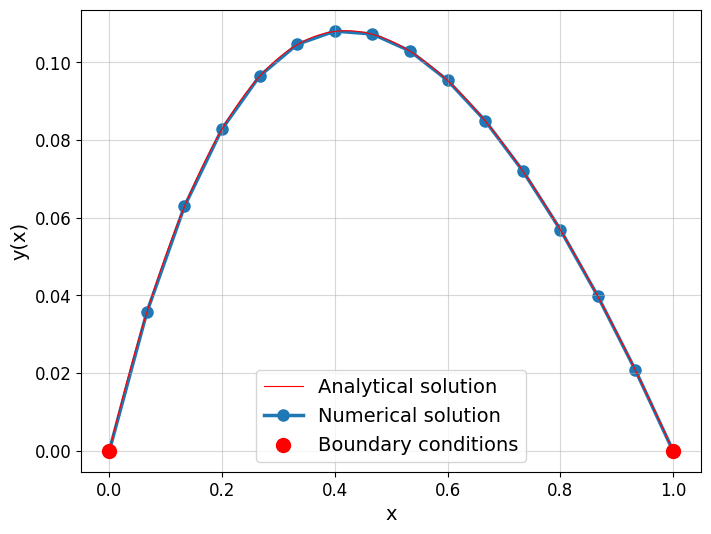

In [8]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)
nd = np.linspace(0, 1, n, endpoint=True)
nd_fine = np.linspace(0, 1, 200, endpoint=True)
rel_sol = C1 * np.exp(k1 * nd_fine) + C2 * np.exp(k2 * nd_fine) + 1
plt.plot( nd_fine,rel_sol,color='red', lw=0.8, ms=0, label="Analytical solution", zorder=3)
plt.plot(nd, x_all, '-o',lw=2.5, ms=8, label="Numerical solution", zorder=1)

plt.scatter((a, bx), (y0, y1), color='red', s=100, label="Boundary conditions", zorder=2)

# !!!
plt.xlabel('x', fontsize=14)
plt.ylabel('y(x)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=14)

plt.show()

-0.0265416308


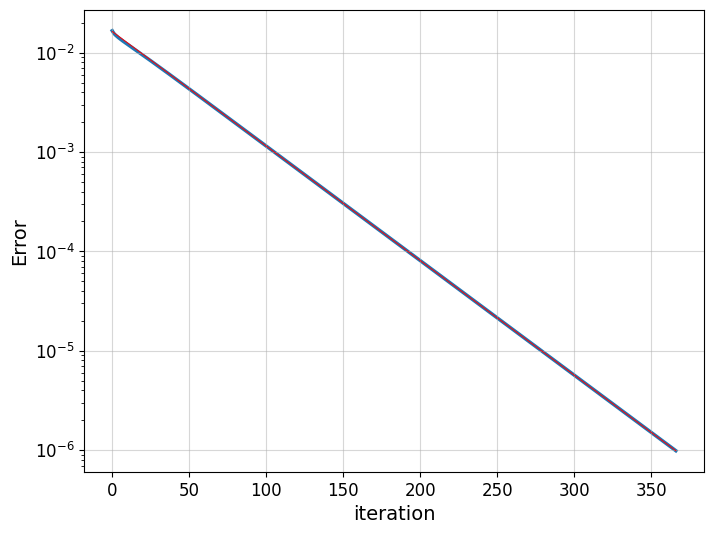

In [9]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

steps = np.arange(0, len(err), dtype=int)

half = len(err) // 2
x = steps[half:]
y=np.log(err[half:])
n = len(x)
all_x = np.sum(x)
all_y = np.sum(y)
all_xx = np.sum(x**2)
all_xy = np.sum(x*y)
a = (n*all_xy - all_x*all_y) / (n*all_xx - all_x**2)
b = (all_y - a*all_x) / n
err1 = np.exp(a*steps + b)

plt.plot(steps, err1, lw=0.7, color='red', zorder=2)
plt.plot(steps, err, lw=2.5, zorder=1)

plt.xlabel('iteration', fontsize=14)
plt.ylabel('Error', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.yscale('log')
print(f"{a:.10f}")
plt.show()

In [10]:
ns = [int(2**i) for i in range(1, 10)]

n_hist = []
iter_hist = []
for n in ns:
    A, b = generate_system(n)
    x_all,err, iter_needed = solve(A, b)

    n_hist.append(n)
    iter_hist.append(iter_needed)

генератоp, k=-1, n=2


  0%|                                                                                                                                                 | 0/10000000 [00:00<?, ?it/s]


успех😎
генератоp, k=-1, n=4


  0%|                                                                                                                                     | 15/10000000 [00:00<09:24, 17707.45it/s]


успех😎
генератоp, k=-1, n=8


...

генератоp, k=-1, n=256


  1%|▊                                                                                                                                 | 59828/10000000 [00:01<03:51, 42852.50it/s]


успех😎
генератоp, k=-1, n=512


  2%|██▌                                                                                                                              | 194792/10000000 [00:10<08:24, 19437.93it/s]

успех😎


1.78307366664191


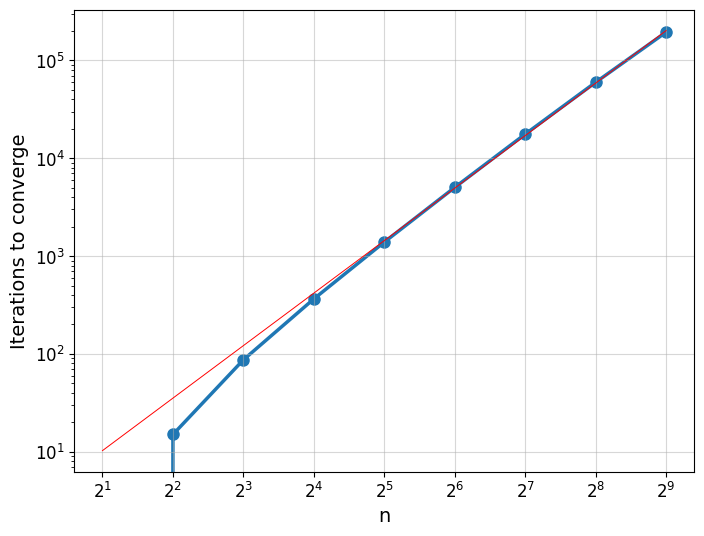

In [11]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)
half = len(n_hist) // 2
x = np.log(n_hist[half:])
y=np.log(iter_hist[half:])
n = len(x)
all_x = np.sum(x)
all_y = np.sum(y)
all_xx = np.sum(x**2)
all_xy = np.sum(x*y)
a = (n*all_xy - all_x*all_y) / (n*all_xx - all_x**2)
b = (all_y - a*all_x) / n
err1 = np.exp(b) * (n_hist**a)
plt.plot(n_hist, err1, lw=0.7, color='red', zorder=2)
plt.plot(n_hist, iter_hist, '-o', lw=2.5, ms=8, zorder=1)

# !!!
plt.xlabel('n', fontsize=14)
plt.ylabel('Iterations to converge', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xscale('log', base=2)
plt.yscale('log', base=10)
print(a)
plt.show()

a1=-0.0265
a2=1.78